1. Data Overview
Shape: 1460 rows, 81 columns. Target variable: SalePrice. 
19 columns contain missing values, dominated by PoolQC (1453), MiscFeature (1406), and Alley (1369).

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

df = pd.read_csv('train.csv')

print("Shape:", df.shape)
print("\nTarget variable: SalePrice")
print(f"Price range: ${df['SalePrice'].min():,} — ${df['SalePrice'].max():,}")
print(f"Mean price: ${df['SalePrice'].mean():,.0f}")

Shape: (1460, 81)

Target variable: SalePrice
Price range: $34,900 — $755,000
Mean price: $180,921


In [26]:
# Missing data analysis
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})

print(missing_df)

              Missing Count  Missing Percentage
PoolQC                 1453           99.520548
MiscFeature            1406           96.301370
Alley                  1369           93.767123
Fence                  1179           80.753425
MasVnrType              872           59.726027
FireplaceQu             690           47.260274
LotFrontage             259           17.739726
GarageType               81            5.547945
GarageYrBlt              81            5.547945
GarageFinish             81            5.547945
GarageQual               81            5.547945
GarageCond               81            5.547945
BsmtFinType2             38            2.602740
BsmtExposure             38            2.602740
BsmtFinType1             37            2.534247
BsmtCond                 37            2.534247
BsmtQual                 37            2.534247
MasVnrArea                8            0.547945
Electrical                1            0.068493


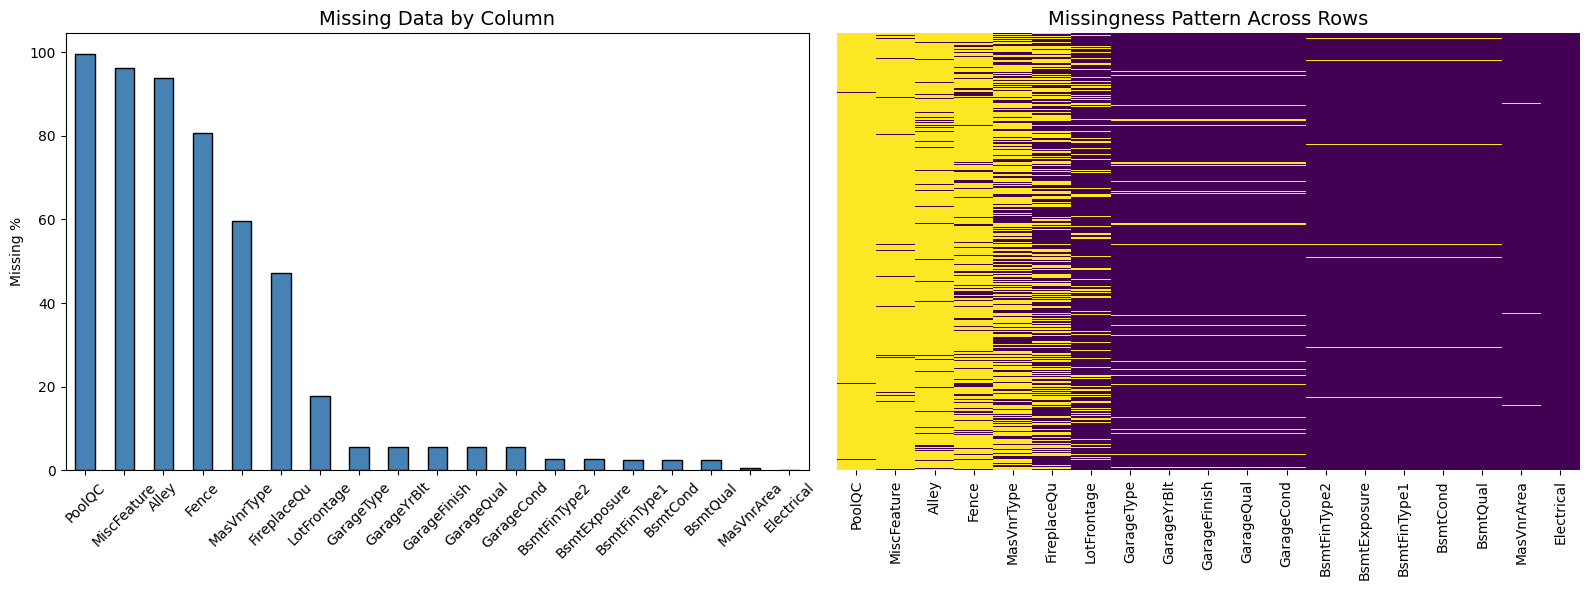

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of missing percentages
missing_pct.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Missing Data by Column', fontsize=14)
axes[0].set_ylabel('Missing %')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Heatmap of missingness pattern
missing_cols = missing.index.tolist()
sns.heatmap(df[missing_cols].isnull(), 
            yticklabels=False, 
            cbar=False, 
            cmap='viridis',
            ax=axes[1])
axes[1].set_title('Missingness Pattern Across Rows', fontsize=14)

plt.tight_layout()
plt.show()

## 2. Target Variable Analysis
SalePrice is significantly right-skewed (skewness = 1.88). 
Applied log transformation to normalize distribution (post-transform skewness = 0.12).

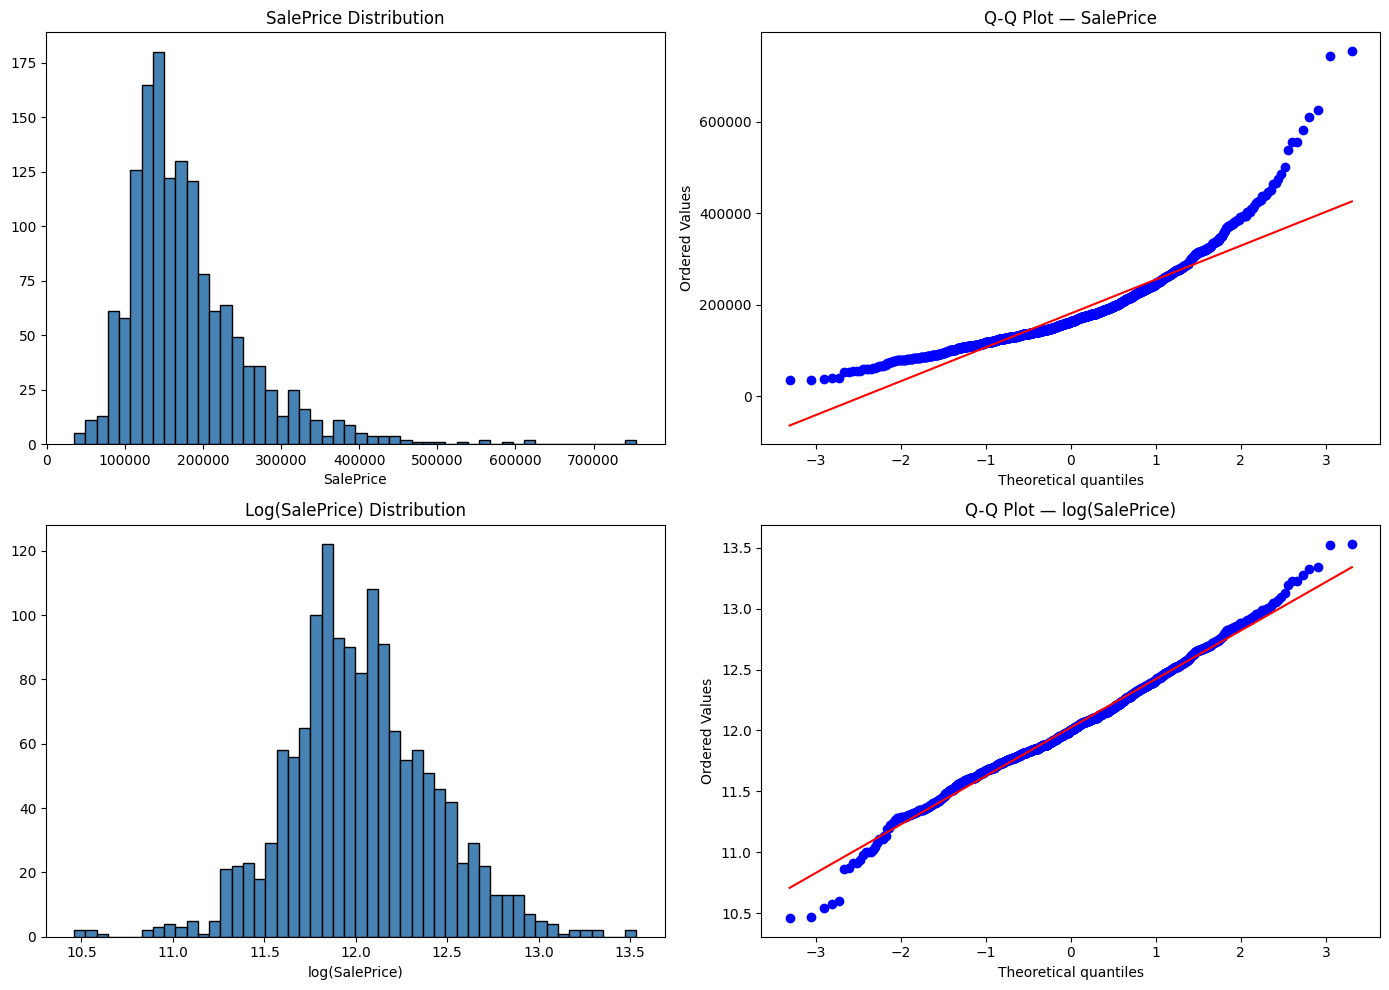

Original skewness: 1.8829
Log skewness: 0.1213


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original distribution
axes[0,0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
axes[0,0].set_title('SalePrice Distribution')
axes[0,0].set_xlabel('SalePrice')

# Original Q-Q
stats.probplot(df['SalePrice'], dist="norm", plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot — SalePrice')

# Log transformed
axes[1,0].hist(np.log(df['SalePrice']), bins=50, color='steelblue', edgecolor='black')
axes[1,0].set_title('Log(SalePrice) Distribution')
axes[1,0].set_xlabel('log(SalePrice)')

# Log Q-Q
stats.probplot(np.log(df['SalePrice']), dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot — log(SalePrice)')

plt.tight_layout()
plt.show()

print(f"Original skewness: {df['SalePrice'].skew():.4f}")
print(f"Log skewness: {np.log(df['SalePrice']).skew():.4f}")

df['LogSalePrice'] = np.log(df['SalePrice'])

In [29]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)
df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)

print("New features created:")
print(df[['TotalSF', 'HouseAge', 'RemodAge', 'HasPool', 
          'HasGarage', 'Has2ndFloor', 'HasBsmt']].describe())

New features created:
            TotalSF     HouseAge     RemodAge      HasPool    HasGarage  \
count   1460.000000  1460.000000  1460.000000  1460.000000  1460.000000   
mean    2567.048630    36.547945    22.950000     0.004795     0.944521   
std      821.714421    30.250152    20.640653     0.069100     0.228992   
min      334.000000     0.000000    -1.000000     0.000000     0.000000   
25%     2009.500000     8.000000     4.000000     0.000000     1.000000   
50%     2474.000000    35.000000    14.000000     0.000000     1.000000   
75%     3004.000000    54.000000    41.000000     0.000000     1.000000   
max    11752.000000   136.000000    60.000000     1.000000     1.000000   

       Has2ndFloor      HasBsmt  
count  1460.000000  1460.000000  
mean      0.432192     0.974658  
std       0.495550     0.157217  
min       0.000000     0.000000  
25%       0.000000     1.000000  
50%       0.000000     1.000000  
75%       1.000000     1.000000  
max       1.000000     1.00000

## 3. Feature Selection
Selected features via correlation analysis and multicollinearity check.
Dropped GarageArea (0.88 correlation with GarageCars), 1stFlrSF (0.82 with TotalBsmtSF), 
GarageYrBlt (0.83 with YearBuilt). Final features: OverallQual, GrLivArea, GarageCars, 
TotalBsmtSF, FullBath, YearBuilt.

In [30]:
# Drop columns with more than 50% missing — too much to impute reliably
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                'Id', 'SalePrice', 'LogSalePrice']

df_model = df.drop(columns=cols_to_drop)

# Separate numeric and categorical
numeric_cols = df_model.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

# Correlation of numeric features with log target
correlations = df_model[numeric_cols].corrwith(df['LogSalePrice']).abs().sort_values(ascending=False)
print("\nTop 20 numeric features by correlation:")
print(correlations.head(20))

Numeric features: 43
Categorical features: 38

Top 20 numeric features by correlation:
OverallQual     0.817184
TotalSF         0.777296
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
HouseAge        0.587290
YearBuilt       0.586570
RemodAge        0.568136
YearRemodAdd    0.565608
GarageYrBlt     0.541073
TotRmsAbvGrd    0.534422
Fireplaces      0.489449
MasVnrArea      0.430809
BsmtFinSF1      0.372023
LotFrontage     0.355878
WoodDeckSF      0.334135
HasGarage       0.322999
dtype: float64


In [31]:
# Remove outliers on GrLivArea
Q1 = df['GrLivArea'].quantile(0.25)
Q3 = df['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[(df['GrLivArea'] >= Q1 - 1.5*IQR) & 
              (df['GrLivArea'] <= Q3 + 1.5*IQR)].copy()

print(f"Rows before: {df.shape[0]}")
print(f"Rows after: {df_clean.shape[0]}")
print(f"Removed: {df.shape[0] - df_clean.shape[0]}")

# Recreate engineered features on clean df
df_clean['TotalSF'] = df_clean['TotalBsmtSF'] + df_clean['1stFlrSF'] + df_clean['2ndFlrSF']
df_clean['HouseAge'] = df_clean['YrSold'] - df_clean['YearBuilt']
df_clean['RemodAge'] = df_clean['YrSold'] - df_clean['YearRemodAdd']
df_clean['HasPool'] = (df_clean['PoolArea'] > 0).astype(int)
df_clean['HasGarage'] = (df_clean['GarageArea'] > 0).astype(int)
df_clean['Has2ndFloor'] = (df_clean['2ndFlrSF'] > 0).astype(int)
df_clean['HasBsmt'] = (df_clean['TotalBsmtSF'] > 0).astype(int)
df_clean['LogSalePrice'] = np.log(df_clean['SalePrice'])

Rows before: 1460
Rows after: 1429
Removed: 31


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Define final feature sets
numeric_features = ['OverallQual', 'TotalSF', 'GrLivArea', 'GarageCars',
                    'TotalBsmtSF', 'FullBath', 'YearBuilt', 'HouseAge',
                    'RemodAge', 'HasGarage', 'HasBsmt', 'Has2ndFloor']

categorical_features = ['Neighborhood', 'MSZoning', 'SaleCondition',
                        'BldgType', 'HouseStyle', 'RoofStyle']

# Numeric pipeline — impute with median, then scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline — impute with most frequent, then encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

# Define X and y
X = df_clean[numeric_features + categorical_features]
y = df_clean['LogSalePrice']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

X_train: (1143, 18)
X_test: (286, 18)


In [33]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

def evaluate(y_test, y_pred, model_name, train_time):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name}: MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f} | Time={train_time:.2f}s")
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}

results = []

# 1. Linear Regression
lr_pipeline = Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())])
start = time.time()
lr_pipeline.fit(X_train, y_train)
results.append(evaluate(y_test, lr_pipeline.predict(X_test), 'Linear Regression', time.time()-start))

# 2. Ridge with RandomizedSearchCV
ridge_pipeline = Pipeline([('preprocessor', preprocessor), ('model', Ridge())])
ridge_params = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 200.0]}
ridge_search = RandomizedSearchCV(ridge_pipeline, ridge_params, n_iter=7, cv=5, 
                                   scoring='r2', random_state=42)
start = time.time()
ridge_search.fit(X_train, y_train)
print(f"Best Ridge alpha: {ridge_search.best_params_}")
results.append(evaluate(y_test, ridge_search.predict(X_test), 'Ridge', time.time()-start))

# 3. Lasso with RandomizedSearchCV
lasso_pipeline = Pipeline([('preprocessor', preprocessor), ('model', Lasso(max_iter=10000))])
lasso_params = {'model__alpha': [0.0001, 0.001, 0.01, 0.1, 0.5]}
lasso_search = RandomizedSearchCV(lasso_pipeline, lasso_params, n_iter=5, cv=5,
                                   scoring='r2', random_state=42)
start = time.time()
lasso_search.fit(X_train, y_train)
print(f"Best Lasso alpha: {lasso_search.best_params_}")
results.append(evaluate(y_test, lasso_search.predict(X_test), 'Lasso', time.time()-start))

# 4. ElasticNet with RandomizedSearchCV
en_pipeline = Pipeline([('preprocessor', preprocessor), ('model', ElasticNet(max_iter=10000))])
en_params = {'model__alpha': [0.0001, 0.001, 0.01, 0.1],
             'model__l1_ratio': [0.2, 0.5, 0.7, 0.9]}
en_search = RandomizedSearchCV(en_pipeline, en_params, n_iter=8, cv=5,
                                scoring='r2', random_state=42)
start = time.time()
en_search.fit(X_train, y_train)
print(f"Best ElasticNet params: {en_search.best_params_}")
results.append(evaluate(y_test, en_search.predict(X_test), 'ElasticNet', time.time()-start))

# 5. Polynomial Regression
poly_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge(alpha=10.0))
])
start = time.time()
poly_pipeline.fit(X_train, y_train)
results.append(evaluate(y_test, poly_pipeline.predict(X_test), 'Polynomial (deg 2)', time.time()-start))

# 6. Gradient Boosting
gb_pipeline = Pipeline([('preprocessor', preprocessor),
                         ('model', GradientBoostingRegressor(n_estimators=200, 
                                                              random_state=42))])
start = time.time()
gb_pipeline.fit(X_train, y_train)
results.append(evaluate(y_test, gb_pipeline.predict(X_test), 'Gradient Boosting', time.time()-start))

Linear Regression: MAE=0.0920 | RMSE=0.1273 | R²=0.8854 | Time=0.05s
Best Ridge alpha: {'model__alpha': 10.0}
Ridge: MAE=0.0912 | RMSE=0.1280 | R²=0.8841 | Time=0.48s
Best Lasso alpha: {'model__alpha': 0.0001}
Lasso: MAE=0.0911 | RMSE=0.1263 | R²=0.8872 | Time=0.53s
Best ElasticNet params: {'model__l1_ratio': 0.5, 'model__alpha': 0.001}
ElasticNet: MAE=0.0909 | RMSE=0.1275 | R²=0.8851 | Time=0.88s
Polynomial (deg 2): MAE=0.0987 | RMSE=0.1411 | R²=0.8591 | Time=0.07s
Gradient Boosting: MAE=0.0934 | RMSE=0.1335 | R²=0.8740 | Time=0.54s


In [34]:
print("5-Fold Cross Validation R² Scores:")
print("-" * 55)

best_pipelines = {
    'Linear Regression': lr_pipeline,
    'Ridge': ridge_search.best_estimator_,
    'Lasso': lasso_search.best_estimator_,
    'ElasticNet': en_search.best_estimator_,
    'Polynomial': poly_pipeline,
    'Gradient Boosting': gb_pipeline
}

cv_results = {}
for name, pipeline in best_pipelines.items():
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f"{name}: mean={scores.mean():.4f} | std={scores.std():.4f}")

5-Fold Cross Validation R² Scores:
-------------------------------------------------------
Linear Regression: mean=0.8728 | std=0.0149
Ridge: mean=0.8757 | std=0.0122
Lasso: mean=0.8751 | std=0.0147
ElasticNet: mean=0.8756 | std=0.0125
Polynomial: mean=0.8454 | std=0.0229
Gradient Boosting: mean=0.8637 | std=0.0121



## 4. Outlier Removal
Removed 31 outliers from GrLivArea using IQR method. Dataset: 1460 → 1429 rows.


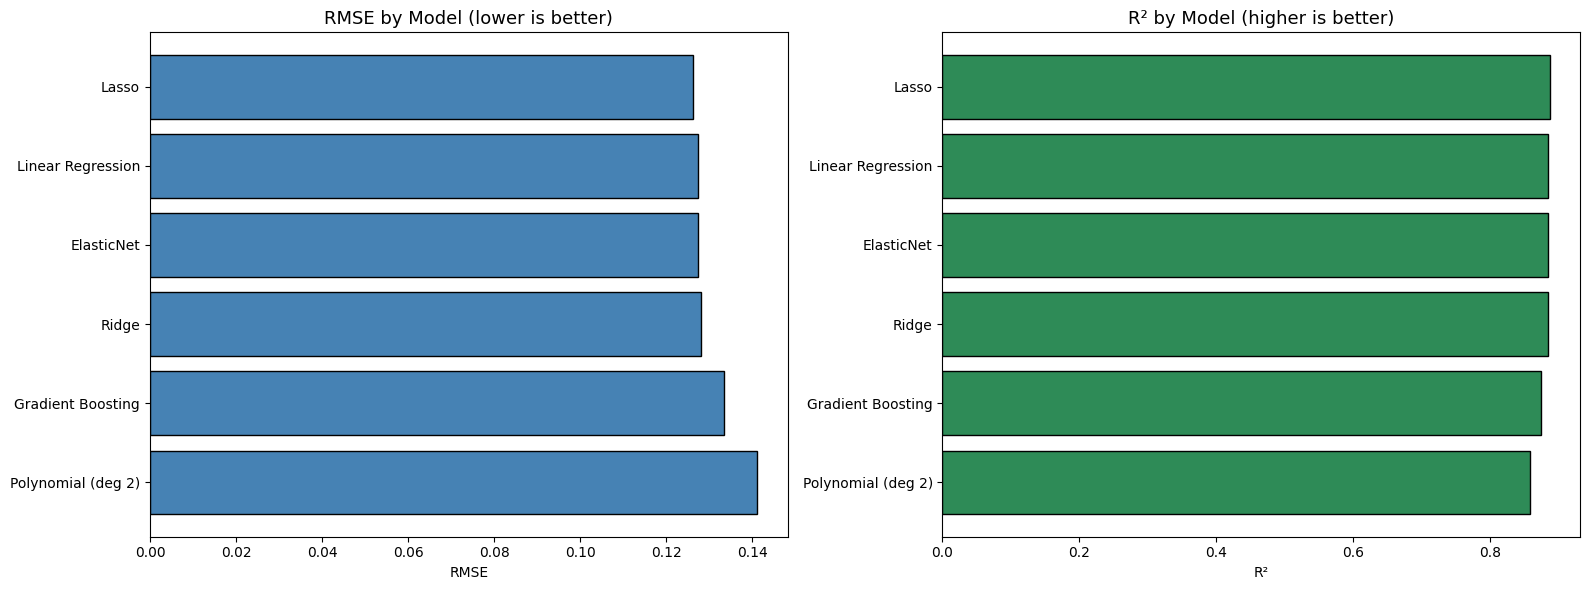


FINAL MODEL COMPARISON
             Model      MAE     RMSE       R2     Time
             Lasso 0.091090 0.126304 0.887187 0.531604
 Linear Regression 0.091975 0.127307 0.885388 0.048768
        ElasticNet 0.090927 0.127464 0.885105 0.881407
             Ridge 0.091190 0.128002 0.884133 0.475919
 Gradient Boosting 0.093395 0.133469 0.874023 0.536654
Polynomial (deg 2) 0.098654 0.141139 0.859129 0.073314


In [36]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RMSE comparison
axes[0].barh(results_df['Model'], results_df['RMSE'], color='steelblue', edgecolor='black')
axes[0].set_title('RMSE by Model (lower is better)', fontsize=13)
axes[0].set_xlabel('RMSE')
axes[0].invert_yaxis()

# R² comparison
axes[1].barh(results_df['Model'], results_df['R2'], color='seagreen', edgecolor='black')
axes[1].set_title('R² by Model (higher is better)', fontsize=13)
axes[1].set_xlabel('R²')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n" + "="*65)
print("FINAL MODEL COMPARISON")
print("="*65)
print(results_df.to_string(index=False))
print("="*65)

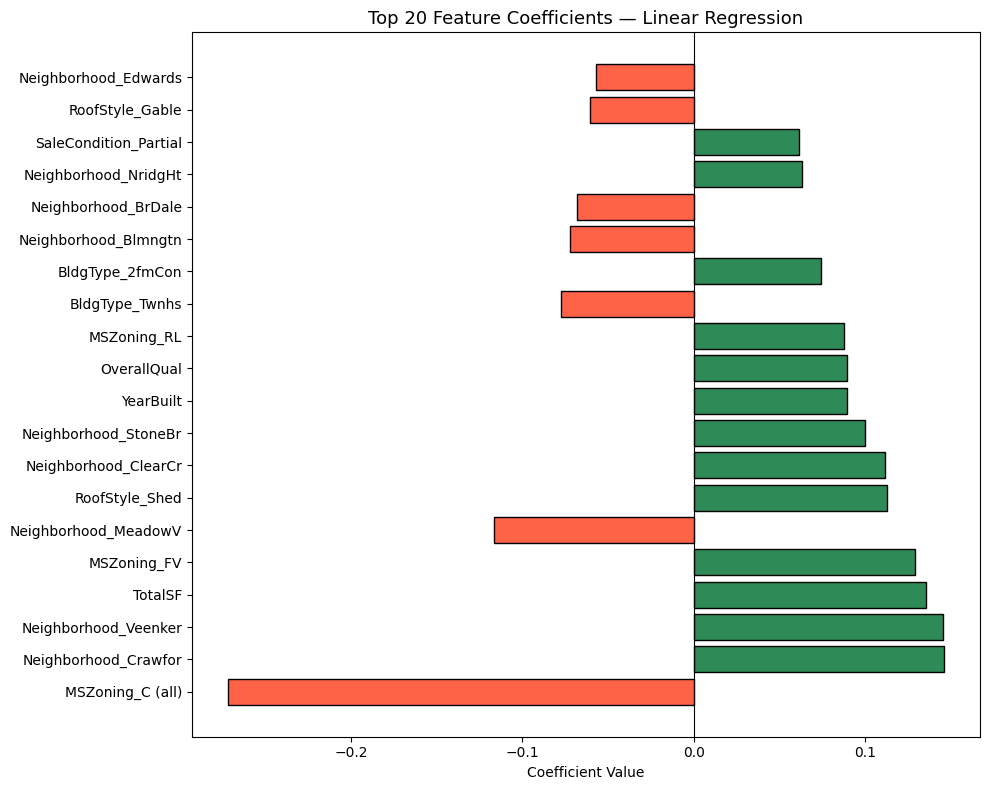

In [37]:
# Get coefficients from Linear Regression
lr_model = lr_pipeline.named_steps['model']
preprocessor_fitted = lr_pipeline.named_steps['preprocessor']

# Get feature names after encoding
ohe_features = preprocessor_fitted.named_transformers_['categorical']\
                .named_steps['encoder'].get_feature_names_out(categorical_features)
all_features = numeric_features + list(ohe_features)

coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(20)

plt.figure(figsize=(10, 8))
colors = ['seagreen' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 20 Feature Coefficients — Linear Regression', fontsize=13)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

Best model: Ridge


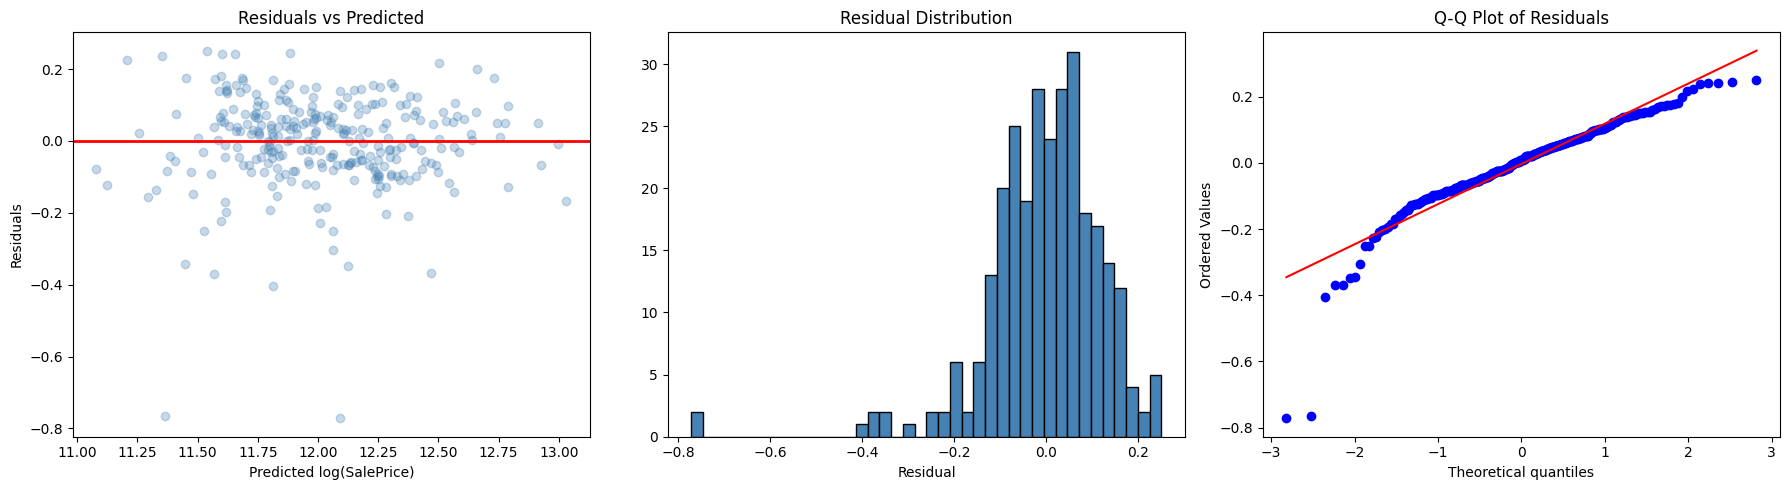

Residual mean: -0.003283
Residual std: 0.1280

10 Worst Predictions:
     Actual  Predicted  Error (log)
0   82500.0  178515.49        -0.77
1   40000.0   86053.54        -0.77
2   90000.0  134787.10        -0.40
3   73000.0  105690.08        -0.37
4  180000.0  260153.02        -0.37
5  130000.0  184281.02        -0.35
6   66500.0   93765.65        -0.34
7  127500.0  172883.68        -0.30
8  132000.0  102698.01         0.25
9  135000.0  173507.99        -0.25


In [41]:
# --- Section 12 — Residual Analysis on Best Model (FIXED) ---

# Use best model from CV results
best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"Best model: {best_model_name}")

best_pipeline = best_pipelines[best_model_name]

# Predictions — keep as NumPy for speed, but align indices when needed
y_pred_best = best_pipeline.predict(X_test)
residuals = y_test.values - y_pred_best   # both are now plain arrays

# 1. Residual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.3, color='steelblue')
axes[0].axhline(y=0, color='red', linewidth=2)
axes[0].set_xlabel('Predicted log(SalePrice)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.6f}")
print(f"Residual std: {residuals.std():.4f}")

# 2. Worst predictions — sorted by absolute residual
abs_residuals = np.abs(residuals)
worst_indices = np.argsort(abs_residuals)[-10:][::-1]  # indices of 10 largest

print("\n10 Worst Predictions:")
print(pd.DataFrame({
    'Actual':        np.exp(y_test.values[worst_indices]),
    'Predicted':     np.exp(y_pred_best[worst_indices]),
    'Error (log)':   residuals[worst_indices]
}).round(2))

In [40]:
import joblib

joblib.dump(best_pipeline, 'best_model_pipeline.joblib')
print(f"Model saved: best_model_pipeline.joblib")
print(f"Best model: {best_model_name}")
print(f"CV R²: {cv_results[best_model_name].mean():.4f} ± {cv_results[best_model_name].std():.4f}")

Model saved: best_model_pipeline.joblib
Best model: Ridge
CV R²: 0.8757 ± 0.0122
